### Import and reading data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import os
# import ctypes

# # Force the dynamic linker to find libR.so before rpy2 tries to load
# try:
#     ctypes.CDLL('/usr/lib/R/lib/libR.so', mode=ctypes.RTLD_GLOBAL)
# except Exception as e:
#     print(f"Manual link failed: {e}")

# os.environ['R_HOME'] = '/usr/lib/R'
# os.environ['LD_LIBRARY_PATH'] = '/usr/lib/R/lib'

In [3]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import numpy as np
import pandas as pd



In [4]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
# os.chdir('/home/dell/projects/graphical-sampling/simulations')
os.chdir('/home/bardia/projects/graphical-sampling/simulations')


In [5]:
# ============================================================
# DESIGN SEARCH FUNCTION
# ============================================================

def search_best_design(

    pop,
    n,

    # ========================================================
    # CRITERION
    # ========================================================

    criterion='MI',

    # ========================================================
    # MULTI-OBJECTIVE WEIGHTS
    # ========================================================

    w1=0.5,
    w2=0.5,

    moran_scale=0.05,
    var_scale=1000,

    # ========================================================
    # SEARCH SPACE
    # ========================================================

    point_strategies=[

        'None',

        'lexico_xy',
        'lexico_yx',

        'projection',
        'dist_from_origin',

        'angle',
        'spiral',

        'hilbert',

        'snake',

        'knight_move',

        'random',
    ],

    zone_strategies=[

        'None',

        'lexico_xy',
        'lexico_yx',

        'projection',
        'dist_from_origin',

        'angle',
        'spiral',

        'hilbert',

        'snake',

        'knight_move',

        'random',
    ],

    zone_modes=[
        'sweep_xy',
        'sweep_yx'
    ],

    num_splits=[1],

    shift_jumps=[1],

    num_zones_cluster=[100],

    num_zones_sweep=[(5, 5)],

    # ========================================================
    # CLUSTERING
    # ========================================================

    centroid_grid_x=10,

    r_sample_per_cluster=1,

    # ========================================================
    # ORDER OPTIONS
    # ========================================================

    topological=False,

    shuffle=False,
):

    # ========================================================
    # CRITERION NAMES
    # ========================================================

    criterion_name_map = {

        'MI': 'Moran',

        'VAR': 'Variance',

        'MI_VAR': 'Moran + Variance',

        'VI': 'Voronoi',

        'DI': 'Density',

        'BI': 'Balance',
    }

    criterion_name = criterion_name_map[criterion]

    # ========================================================
    # STORAGE
    # ========================================================

    track = []

    best_val = float('inf')

    best_design = None

    # ========================================================
    # TOTAL ITERATIONS
    # ========================================================

    num_designs = (

        len(point_strategies)

        * len(zone_strategies)

        * len(zone_modes)

        * len(num_splits)

        * len(shift_jumps)
    )

    # ========================================================
    # PROGRESS BAR
    # ========================================================

    pbar = tqdm(

        product(

            point_strategies,

            zone_strategies,

            zone_modes,

            num_splits,

            shift_jumps
        ),

        total=num_designs
    )

    # ========================================================
    # SEARCH LOOP
    # ========================================================

    for (

        point_strategy,

        zone_strategy,

        zone_mode,

        num_split,

        shift_jump

    ) in pbar:

        # ----------------------------------------------------
        # ZONE CONFIGURATIONS
        # ----------------------------------------------------

        list_of_num_zones = (

            num_zones_cluster

            if zone_mode == 'cluster'

            else num_zones_sweep
        )

        for num_zones in list_of_num_zones:

            # =================================================
            # CLUSTERING
            # =================================================

            fbn = gs.clustering.FIPBalancedNMeans(

                n=n,

                centroid_grid_x=centroid_grid_x,

                r_sample_per_cluster=r_sample_per_cluster,

                init_clust_method='expanded',

                split_size=1
            )

            fbn.fit(pop)

            fbn.fit_zones(

                num_zones=num_zones,

                mode=zone_mode
            )

            try:

                # =============================================
                # BUILD ORDER
                # =============================================

                order = gs.Order.from_clusters(

                    pop,

                    fbn.clusters,

                    zone_strategy=zone_strategy,

                    point_strategy=point_strategy,

                    num_splits=num_split,

                    topological=topological,

                    shift_jump=shift_jump,

                    shuffle=shuffle,

                    grid_dims=(
                        num_zones
                        if isinstance(num_zones, tuple)
                        else None
                    ),
                )

                # =============================================
                # CREATE DESIGN
                # =============================================

                design = gs.Design.from_order(pop, order)

                # =============================================
                # CRITERIA
                # =============================================

                moran_val = design.moran[0]

                design._nht_variance = None

                var_val = design.nht_variance

                # =============================================
                # OBJECTIVE FUNCTION
                # =============================================

                match criterion:

                    case 'MI':

                        val = moran_val

                    case 'VAR':

                        val = var_val

                    case 'MI_VAR':

                        standardized_moran = (
                            moran_val
                            / (moran_scale + 1e-12)
                        )

                        standardized_variance = (
                            var_val
                            / (var_scale + 1e-12)
                        )

                        val = (

                            w1 * standardized_moran

                            +

                            w2 * standardized_variance
                        )

                    case 'VI':

                        val = design.voronoi

                    case 'DI':

                        val = design.density_disparity

                    case 'BI':

                        val = design.local_balance

                    case _:

                        raise ValueError(
                            f"Unknown criterion: {criterion}"
                        )

                # =============================================
                # LABELS
                # =============================================

                combo = (
                    f"{zone_strategy}"
                    f" → "
                    f"{point_strategy}"
                )

                # =============================================
                # INITIAL BASELINE
                # =============================================

                if len(track) == 0:

                    best_val = val

                    print(

                        f"[INITIAL] "

                        f"{criterion_name}: {val:.6f} | "

                        f"{combo}"
                    )

                # =============================================
                # IMPROVEMENT
                # =============================================

                if val < best_val:

                    best_val = val

                    best_design = design

                    print(

                        f"[NEW BEST] "

                        f"Objective: {val:.6f} | "

                        f"MI: {moran_val:.6f} | "

                        f"VAR: {var_val:.2f} | "

                        f"{combo:<30} | "

                        f"Mode: {zone_mode:<8} | "

                        f"Zones: {num_zones} | "

                        f"Jump: {shift_jump}"
                    )
                # =============================================
                # PROGRESS BAR
                # =============================================

                pbar.set_postfix({

                    "Best": f"{best_val:.6f}",

                    "Combo": combo
                })

                # =============================================
                # STORE RESULTS
                # =============================================

                track.append({

                    'value': val,

                    'design': design,

                    'moran': moran_val,

                    'variance': var_val,

                    'zone_strategy': zone_strategy,

                    'point_strategy': point_strategy,

                    'combo': combo,

                    'zone_mode': zone_mode,

                    'num_zones': num_zones,

                    'shift_jump': shift_jump,
                })

            except Exception:

                continue

    # ========================================================
    # NO VALID DESIGNS
    # ========================================================

    if len(track) == 0:

        print("\n[ERROR] No valid designs generated.")

        return None

    # ========================================================
    # SORT RESULTS
    # ========================================================

    results = sorted(

        track,

        key=lambda x: x['value']
    )

    best = results[0]

    # ========================================================
    # FINAL OUTPUT
    # ========================================================

    print(f"\n{'='*60}")

    print(f"              OPTIMIZATION COMPLETE")

    print(f"{'='*60}")

    print(f"Criterion:       {criterion_name}")

    print(f"Best Objective:  {best['value']:.6f}")

    print(f"Moran:           {best['moran']:.6f}")

    print(f"Variance:        {best['variance']:.6f}")

    print(f"Combination:     {best['combo']}")

    print(f"Zone Mode:       {best['zone_mode']}")

    print(f"Num Zones:       {best['num_zones']}")

    print(f"Shift Jump:      {best['shift_jump']}")

    print(f"{'='*60}")

    # ========================================================
    # RETURN
    # ========================================================

    return {

        'best_design': best['design'],

        'best_value': best['value'],

        'criterion': criterion,

        'moran': best['moran'],

        'variance': best['variance'],

        'best_combo': best['combo'],

        'zone_strategy': best['zone_strategy'],

        'point_strategy': best['point_strategy'],

        'zone_mode': best['zone_mode'],

        'num_zones': best['num_zones'],

        'shift_jump': best['shift_jump'],

        'results': results,

        'track': track,
    }

In [6]:
def robertson_variables(x1, x2, positive_shift=True):

    corrugated = (
        3 * (x1 + x2)
        +
        np.sin(6 * (x1 + x2))
    )

    peak = (
        (
            3 * (4 - 6*x1)**2
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 2)**2
            )
            -
            10
            *
            (
                0.2*(6*x1 - 3)
                -
                (6*x1 - 3)**3
                -
                (6*x2 - 3)**5
            )
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 3)**2
            )
            -
            (1/3)
            *
            np.exp(
                -(6*x1 - 2)**2
                -
                (6*x2 - 3)**2
            )
        )
    )

    bird = (
        1/20
        *
        (
            (12*x1 - 12*x2)**2
            +
            np.exp(
                (1 - np.sin(12*x1 - 6))**2
            )
            *
            np.cos(12*x2 - 6)
            +
            np.exp(
                (1 - np.cos(12*x2 - 6))**2
            )
            *
            np.sin(12*x1 - 6)
        )
    )

    if positive_shift:

        peak = peak + 7

        bird = bird + 6

    return {

        "corrugated": corrugated,

        "plane": corrugated,

        "peak": peak,

        "bird": bird,
    }

In [7]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

import os
import pandas as pd
import numpy as np

from package_sampling.utils import inclusion_probabilities

# =========================================================
# FILES
# =========================================================

files = [

    "meuse.csv",

    "swiss.csv",

    "AggregatedPop1000.csv",

    "RegularPop1000.csv"
]

# =========================================================
# POPULATION LOADER
# =========================================================

def popus(n, path="populations/real"):

    dfs = {}

    for f in files:

        full_path = os.path.join(path, f)

        # -------------------------------------------------
        # Check existence
        # -------------------------------------------------

        if not os.path.exists(full_path):

            print(f"Warning: {full_path} not found.")

            continue

        # -------------------------------------------------
        # Read file
        # -------------------------------------------------

        df = pd.read_csv(full_path)

        N_pop = len(df)

        name = f.replace(".csv", "")

        # -------------------------------------------------
        # Equal probabilities
        # -------------------------------------------------

        pik_ep = np.repeat(
            n / N_pop,
            N_pop
        )


        # =================================================
        # ROBERTSON POPULATIONS
        # =================================================

        # =================================================
# ROBERTSON POPULATIONS
# =================================================

        if f in ["AggregatedPop1000.csv", "RegularPop1000.csv"]:

            coords = df.to_numpy()

            x1 = coords[:, 0]
            x2 = coords[:, 1]

            vars_robertson = robertson_variables(x1, x2)

            plane = vars_robertson["plane"]

            def noisy_through_origin(x, rho, seed=None):

                rng = np.random.default_rng(seed)

                e = rng.normal(size=len(x))
                e = (e - e.mean()) / e.std()

                # noise level corresponding to target correlation
                noise_ratio = np.sqrt(1 / (rho**2) - 1)

                y = x + noise_ratio * x.std() * e

                return y

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : x1,
                "coord_y" : x2,

                "pik_ep" : pik_ep,

                "z" : vars_robertson["corrugated"],

                "plane" : plane,
                "peak" : vars_robertson["peak"],
                "bird" : vars_robertson["bird"],

                "plane_rho_07" : noisy_through_origin(plane, 0.7, seed=701),
                "plane_rho_08" : noisy_through_origin(plane, 0.8, seed=801),
                "plane_rho_09" : noisy_through_origin(plane, 0.9, seed=901),
            })
            
        # if f in ["AggregatedPop1000.csv", "RegularPop1000.csv"]:

        #     coords = df.to_numpy()

        #     x1 = coords[:, 0]
        #     x2 = coords[:, 1]

        #     vars_robertson = robertson_variables(x1, x2)

        #     plane = vars_robertson["plane"]

        #     def correlated_with(x, rho, seed=None):

        #         rng = np.random.default_rng(seed)

        #         x_std = (x - x.mean()) / x.std()

        #         e = rng.normal(size=len(x_std))
        #         e = (e - e.mean()) / e.std()

        #         y_std = rho * x_std + np.sqrt(1 - rho**2) * e

        #         return y_std

        #     dfs[f"df_{name}"] = pd.DataFrame({

        #         "coord_x" : x1,
        #         "coord_y" : x2,

        #         "pik_ep" : pik_ep,

        #         "z" : vars_robertson["corrugated"],

        #         "plane" : plane,
        #         "peak" : vars_robertson["peak"],
        #         "bird" : vars_robertson["bird"],

        #         "plane_rho_07" : correlated_with(plane, 0.7, seed=701),
        #         "plane_rho_08" : correlated_with(plane, 0.99, seed=801),
        #         "plane_rho_09" : correlated_with(plane, 0.9, seed=901),
        #     })

        # =================================================
        # MEUSE
        # =================================================

        elif f == "meuse.csv":

            coords = df[["x", "y"]].to_numpy()

            # unequal probabilities
            pik_up = inclusion_probabilities(

                df["copper"].to_numpy().copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["cadmium"]
            })

        # =================================================
        # SWISS
        # =================================================

        elif f == "swiss.csv":

            coords = df[["x", "y"]].to_numpy()

            AREA = df["AREA"].to_numpy().clip(
                5,
                100
            )

            pik_up = inclusion_probabilities(

                AREA.copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["AREA_A"]
            })

    return dfs

# =========================================================
# LOAD MAIN POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]

aggregated = p50["df_AggregatedPop1000"]

meuse = p50["df_meuse"]

swiss = p50["df_swiss"]

# =========================================================
# CHECK
# =========================================================

print("\n================================================")
print("POPULATIONS LOADED")
print("================================================\n")

print("regular:", regular.shape)

print("aggregated:", aggregated.shape)

print("meuse:", meuse.shape)

print("swiss:", swiss.shape)


POPULATIONS LOADED

regular: (1000, 10)
aggregated: (1000, 10)
meuse: (155, 5)
swiss: (959, 5)


In [8]:
# changing the angle of the population for testing the robustness of the sampling algorithms

import numpy as np
import pandas as pd

def rotate_population(df, alpha_degrees):
    # Convert angle to radians
    alpha_rad = np.radians(alpha_degrees)
    
    # Rotation Matrix components
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Extract coordinates
    x = df['coord_x'].values
    y = df['coord_y'].values
    
    # Apply Rotation:
    # x' = x*cos(a) - y*sin(a)
    # y' = x*sin(a) + y*cos(a)
    df['coord_x'] = x * cos_a - y * sin_a
    df['coord_y'] = x * sin_a + y * cos_a
    
    return df

# Example use: Rotate 45 degrees
# df_rotated = rotate_population(df.copy(), 45)

In [9]:
# Diagnostic function to check inclusion probabilities and plot deviations

import numpy as np
import matplotlib.pyplot as plt

def check_inclusions(design, plot=True, title="FIP Deviation"):
    """
    Performs a statistical diagnostic on the design to ensure 
    Inclusion Probabilities (FIP) are perfectly preserved.
    """
    # 1. Extract Data
    empirical_fip = design.fip 
    target_fip = design.pop.inclusions
    diff = empirical_fip - target_fip
    max_dev = np.abs(diff).max()

    # 2. Print Summary
    print(f"--- Inclusion Probability Diagnostic ---")
    print(f"Total Design Mass: {empirical_fip.sum():.6f} (Target: {design.pop.n})")
    print(f"Max Absolute Deviation: {max_dev:.2e}")
    print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

    # 3. Validation Logic
    if np.allclose(empirical_fip, target_fip, atol=1e-6):
        print("✅ SUCCESS: Inclusion probabilities are perfectly preserved!")
    else:
        fixed_count = len(design.order.fixed_ids)
        print(f"❌ WARNING: Significant deviation! Frozen units: {fixed_count}")

    # 4. Optional Plotting
    if plot:
        plt.figure(figsize=(10, 2))
        plt.plot(diff, color='red', lw=1, alpha=0.7)
        plt.title(f"{title} (Max Dev: {max_dev:.2e})")
        plt.axhline(0, color='black', lw=0.5, ls='--')
        plt.ylabel("Delta")
        plt.xlabel("Unit Index")
        plt.grid(True, alpha=0.2)
        plt.show()

In [10]:
# Function to save the full GBFS engine state, including the search frontier and best design
import os
import pickle
from datetime import datetime

def save_gbfs_state(engine, folder="best_designs"):
    """
    Saves the full GBFS engine state, including the search frontier and best design.
    """
    os.makedirs(folder, exist_ok=True)
    
    # Extract metadata for a clean filename
    pop_label = getattr(engine.best_design.pop, 'label', 'pop').replace(" ", "_")
    score = engine.best_criteria_value
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Detect current zone configuration from the best design
    # This helps identify if the file is a 40Z or 1Z version
    num_clusters = len(engine.best_design.order.clusters)
    num_zones = len(engine.best_design.order.clusters[0].zones) if num_clusters > 0 else 0
    
    filename = f"GRIZZLY_{pop_label}_C{num_clusters}Z{num_zones}_score{score:.4f}_pop_{popu}_{timestamp}.pkl"
    save_path = os.path.join(folder, filename)
    
    with open(save_path, 'wb') as f:
        pickle.dump(engine, f)
    
    print(f"✅ Full search state saved: {save_path}")
    print(f"Candidates waiting in Open Set: {len(engine.open_set)}")
    return save_path

In [11]:
# Function to Save Initila and Best Design, 
import os
import pickle
from datetime import datetime

def save_design(design, folder="best_designs", name_prefix="INITIAL"):
    """
    Save a single Design object.
    """
    os.makedirs(folder, exist_ok=True)

    # Population label
    pop_label = getattr(design.pop, 'label', 'pop').replace(" ", "_")

    # Structure info
    num_clusters = len(design.order.clusters) if design.order.clusters else 1
    num_zones = len(design.order.clusters[0].zones) if design.order.clusters else 1

    # Timestamp
    timestamp = datetime.now().strftime("%m%d_%H%M")

    filename = (
        f"{name_prefix}_{pop_label}"
        f"_C{num_clusters}Z{num_zones}"
        f"_pop_{popu}_{timestamp}.pkl"
    )

    save_path = os.path.join(folder, filename)

    with open(save_path, 'wb') as f:
        pickle.dump(design, f)

    print(f"✅ Design saved: {save_path}")

    return save_path

In [12]:
# Function to load a saved GBFS engine state from the best_designs folder

def load_gbfs_state(filename):
    """
    Loads a saved GBFS engine state from the best_designs folder.
    """
    # Ensure we look in the right folder if only a filename is provided
    if not os.path.exists(filename):
        filename = os.path.join("best_designs", filename)
        
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            loaded_engine = pickle.load(f)
        
        print(f"🚀 Grizzly Resumed!")
        print(f"Best Score Found: {loaded_engine.best_criteria_value:.6f}")
        print(f"Hierarchy State:  {len(loaded_engine.best_design.order.clusters)} Clusters")
        print(f"Frontier Size:    {len(loaded_engine.open_set)} candidates")
        return loaded_engine
    else:
        print(f"❌ File not found: {filename}")
        return None

In [13]:
# Fucntion to load One Design, Best or Initial
import pickle

def load_design(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

In [14]:
def release_full_grizzly(old_engine):
    """
    Takes a restricted engine (40 zones), flattens every single candidate 
    in its open_set, and returns a brand new 'Released' engine.
    """
    print(f"--- Global Release Initiated ---")
    print(f"Processing {len(old_engine.open_set)} candidates from the frontier...")
    
    # 1. First, flatten the absolute best design to use as the "seed"
    flat_best = old_engine.best_design.flatten()
    
    # 2. Create the fresh engine using that flat_best as the initial design
    # This prevents the ValueError: min() arg is empty
    new_engine = gs.search.GreedyBestFirstSearch(initial_designs=[flat_best], criteria=old_engine.criteria)
    
    # 3. Flatten the rest of the Open Set and add them
    flattened_count = 0
    import heapq
    for val, _, move_type, design in old_engine.open_set:
        try:
            # Flatten the candidate
            flat_candidate = design.flatten()
            
            # Avoid duplicating the best_design we already added
            if flat_candidate == flat_best:
                continue
                
            # Push into the new engine's open_set
            heapq.heappush(new_engine.open_set, (val, next(new_engine._counter), 'order_change', flat_candidate))
            flattened_count += 1
        except Exception:
            continue
            
    # 4. Ensure the engine starts with a clean closed_set
    new_engine.closed_set = set()
    
    print(f"✅ Success! New engine populated with {flattened_count + 1} global candidates.")
    print(f"Current Best Score: {new_engine.best_criteria_value:.6f}")
    
    return new_engine

In [15]:
# Debugging function to visualize the swap in the specific zone

from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np
def audit_intelligent_swap(order_obj, coords, idx_i, idx_j, c_idx, z_idx):
    """
    Visualizes the specific zone where a swap is happening.
    """
    plt.figure(figsize=(6, 6))
    
    # 1. Get the specific zone data
    active_zone = order_obj.clusters[c_idx].zones[z_idx]
    zone_indices = active_zone.indices # Use the property to get sorted indices
    
    # 2. Plot all points in the background (faint)
    plt.scatter(coords[:, 0], coords[:, 1], c='gray', s=5, alpha=0.1, label='Population')
    
    # 3. Highlight all points in this SPECIFIC zone
    zone_coords = coords[zone_indices]
    plt.scatter(zone_coords[:, 0], zone_coords[:, 1], c='green', s=20, alpha=0.4, label=f'Zone {z_idx}')
    
    # 4. Draw the Convex Hull of the Zone (The "Green Box")
    if len(zone_coords) >= 3:
        hull = ConvexHull(zone_coords)
        for simplex in hull.simplices:
            plt.plot(zone_coords[simplex, 0], zone_coords[simplex, 1], 'g-', lw=2)
            
    # 5. Highlight the two units being swapped
    # Red = Unit i, Blue = Unit j
    plt.scatter(coords[idx_i, 0], coords[idx_i, 1], c='red', s=100, edgecolors='black', label='Unit I', zorder=5)
    plt.scatter(coords[idx_j, 0], coords[idx_j, 1], c='blue', s=100, edgecolors='black', label='Unit J', zorder=5)
    
    plt.title(f"Cluster {c_idx} | Zone {z_idx} | Swapping ID {idx_i} with {idx_j}")
    plt.legend()
    plt.show()

In [16]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


### Parameters

<Axes: title={'center': 'FIP Balanced 50-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

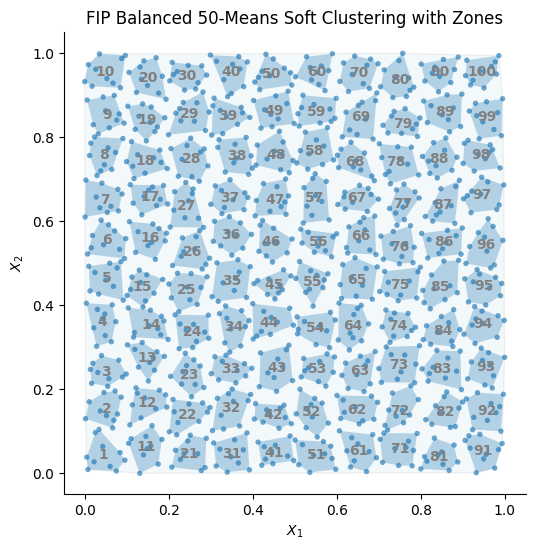

In [17]:
# --- Parameters ---
popu = "df_RegularPop1000"
ep_or_up = "pik_ep"
n = 50

df = popus(n)[popu]
df = rotate_population(df.copy(), 0)
N = len(df)

r_sample_per_cluster = 50
centroid_grid_x = 4
centroid_grid_x_zone = 9
num_zones_cluster = [100]
num_zones_sweep = [(10, 10)]
num_splits = [1]
topological = True
shift_jumps = [0]
shuffle = False

# --- Data Preparation ---
target_df = df

coords_data = target_df[["coord_x", "coord_y"]].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()

# main target: final evaluation
y_main = target_df["plane"].to_numpy()

# auxiliary: optimization variable
y_aux = target_df["plane_rho_08"].to_numpy()

# --- Population uses auxiliary for optimization ---
pop = gs.Population(
    coords_data,
    inclusions_data,
    n=n,
    variable=y_aux
)

# --- Clustering ---
fbn = gs.clustering.FIPBalancedNMeans(
    n=n,
    centroid_grid_x=centroid_grid_x,
    r_sample_per_cluster=r_sample_per_cluster,
    init_clust_method="expanded",
    split_size=1
)

fbn.fit(pop)

fbn.fit_zones(
    num_zones=num_zones_sweep[0],
    mode="sweep_xy"
)

# --- Visualization ---
fbn.plot(mode="soft")

### Pre-Process

In [18]:
# =========================================================
# INITIAL OPTIMIZATION
# =========================================================

y_main = target_df["plane"].to_numpy()
y_aux  = target_df["plane_rho_09"].to_numpy()

print("corr(aux, main) =", np.corrcoef(y_aux, y_main)[0, 1])

pop = gs.Population(
    coords_data,
    inclusions_data,
    n=n,
    variable=y_aux
)

out = search_best_design(
    pop=pop,
    n=n,

    r_sample_per_cluster=1,
    centroid_grid_x=1,
    num_zones_cluster=[100],
    num_zones_sweep=[(1, 1)],
    num_splits=[1],
    topological=True,
    shift_jumps=[0],
    shuffle=False,

    criterion="MI_VAR",

    w1=0.99,
    w2=0.01,

    moran_scale=0.05,
    var_scale=1000,
)

best_initial_design = out["best_design"]

corr(aux, main) = 0.8966326394870973


  0%|          | 1/242 [00:03<12:04,  3.01s/it, Best=-4.741473, Combo=None → None]

[INITIAL] Moran + Variance: -4.741473 | None → None


  1%|          | 3/242 [00:03<04:07,  1.03s/it, Best=-4.741473, Combo=lexico_xy → None]

[NEW BEST] Objective: -4.741473 | MI: -0.255974 | VAR: 32681.81 | lexico_xy → None               | Mode: sweep_xy | Zones: (1, 1) | Jump: 0


 46%|████▌     | 111/242 [00:44<00:49,  2.63it/s, Best=-6.218770, Combo=None → angle]                      

[NEW BEST] Objective: -6.218770 | MI: -0.338684 | VAR: 48718.09 | None → angle                   | Mode: sweep_xy | Zones: (1, 1) | Jump: 0


100%|██████████| 242/242 [01:34<00:00,  2.55it/s, Best=-6.218770, Combo=random → random]               


              OPTIMIZATION COMPLETE
Criterion:       Moran + Variance
Best Objective:  -6.218770
Moran:           -0.338684
Variance:        48718.085963
Combination:     None → angle
Zone Mode:       sweep_xy
Num Zones:       (1, 1)
Shift Jump:      0


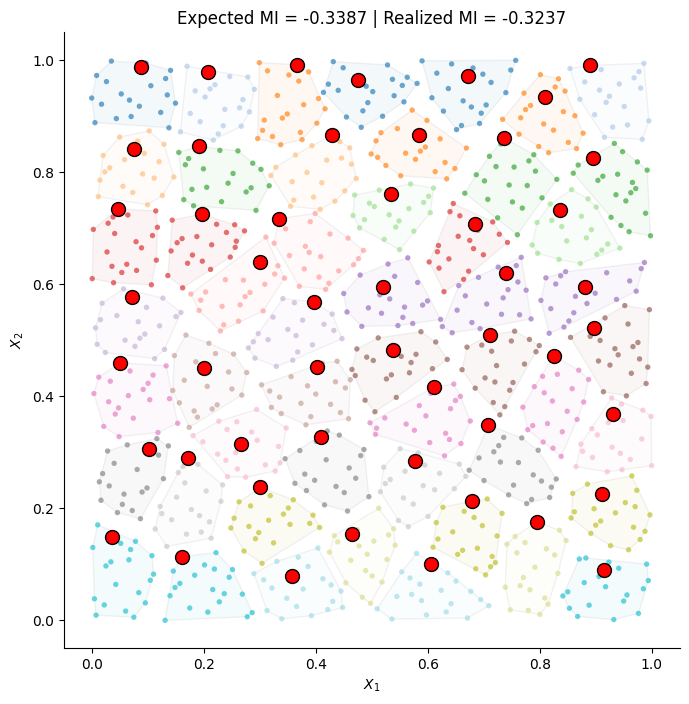

Var aux  /10000: 4.871808596258017
Var main /10000: 2.765170297333181


In [19]:
# =========================================================
# PLOT ONE SAMPLE FROM INITIAL DESIGN
# =========================================================
from graphical_sampling.criteria.multi_objective import nht_variance_for_variable
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

design = best_initial_design

fig, ax = plt.subplots(figsize=(10, 8))

fbn.clusters = design.order.clusters

fbn.plot(
    mode="soft",
    ax=ax,
    show_zone_labels=True
)

sample_2d = design.sample(1)
sample = sample_2d[0]

coords = design.pop.coords

ax.scatter(
    coords[sample, 0],
    coords[sample, 1],
    color="red",
    s=100,
    edgecolors="black",
    zorder=15
)

mi = Moran(
    design.pop,
    method="tille"
).score(sample_2d)[0]

ax.set_title(
    f"Expected MI = {design.moran[0]:.4f} | "
    f"Realized MI = {mi:.4f}"
)

plt.show()

print("Var aux  /10000:",
      nht_variance_for_variable(design, y_aux) / 10000)

print("Var main /10000:",
      nht_variance_for_variable(design, y_main) / 10000)

In [20]:
raise KeyboardInterrupt("Execution stopped by user.")

KeyboardInterrupt: Execution stopped by user.

### GRIZZLY alph MI + (1-alpha) Var

In [21]:
read_des = 1
save_des = 0

read_grz = 0
load_grz = 0

check_des = 0

flat_grz = 0


if save_des == 1:
    # save a design
    current_file = save_design(gbfs.best_design)

if read_des == 1:
    # load a desin
    design = load_design("best_designs/robertson/best_design_C50Z4_Regular1000.pkl")

if read_grz == 1:
    # save a grizzly
    current_file = save_gbfs_state(gbfs)

if load_grz:
    # load a grizzly 
    gbfs = load_gbfs_state('GRIZZLY_pop_C1Z1.pkl')

if check_des == 1:
    check_inclusions(gbfs.best_design)

if flat_grz == 1:
    gbfs = release_full_grizzly(gbfs)


In [23]:
criteria = gs.criteria.MultiObjectiveCriteria(
    objectives=["MI", "VAR"],
    weights=[1, 0],
    scales={"MI": 0.05, "VAR": 15000},
    auxiliary=y_aux,
)
gbfs = gs.search.GreedyBestFirstSearch([design], criteria)

In [25]:
# =========================================================
# RUN GRIZZLY
# =========================================================

gbfs.run(
    max_iterations=1000,
    max_open_set_size=2000,
    top_k=1,

    num_new_order_nodes=100,
    num_new_exchange_nodes=0,

    num_clusters_range=(1, 1),
    num_zones_range=(1, 1),
    num_changes_range=(1, 1),
    num_zone_changes=0,

    pull_strategy="random",
    exchange_coef=0.33,

    num_explore=1,
    window=None,

    n_jobs=-1,
    backtrack_depth=1,
    stagnation_limit=5000,

    y_main=y_main,
    y_aux=y_aux,
)

gbfs.initial_designs = [gbfs.best_design]

check_inclusions(
    gbfs.best_design,
    plot=False
)

Resuming search with 2838 candidates in memory.
--- Parallel GBFS: Batch Size=1, Workers=-1 ---


KeyboardInterrupt: 

###  variance optimization with moran constrain!!!

In [22]:
design.moran

(-0.4652251017407493, 0.022072577835233715)

In [ ]:
class VarianceWithMoranConstraint:
    def __init__(self, mi_max=-0.49, rho=1e5, var_ref=None, moran_method="tille"):
        self.mi_max = mi_max
        self.rho = rho
        self.var_ref = var_ref
        self.moran_method = moran_method

    def __call__(self, design):
        # variance objective
        var = design.nht_variance

        # normalize variance so that penalty scale is meaningful
        if self.var_ref is None:
            var_part = var
        else:
            var_part = var / self.var_ref

        # expected Moran's I of the design
        mi = design.moran[0]

        # penalty only if Moran becomes worse than the allowed bound
        violation = max(0.0, mi - self.mi_max)

        return var_part + self.rho * violation**2

In [ ]:
# -----------------------------------------------
# Stage 1 result: your MI-optimized design
# -----------------------------------------------

mi_design = gbfs.best_design          # the design that reached around -0.50
mi_value  = mi_design.moran[0]
var_ref   = mi_design.nht_variance

print("Starting MI:", mi_value)
print("Starting Var:", var_ref)

# -----------------------------------------------
# Stage 2: optimize variance while preserving MI
# -----------------------------------------------

criteria_var_given_mi = VarianceWithMoranConstraint(
    mi_max=-0.49,
    rho=1e5,
    var_ref=var_ref
)

gbfs2 = gs.search.GreedyBestFirstSearch(
    [mi_design],
    criteria_var_given_mi
)

gbfs2.run(
    max_iterations=2000,
    max_open_set_size=500,
    top_k=20,
    num_new_order_nodes=20,
    num_new_exchange_nodes=20,
    num_clusters_range=(1, 3),
    num_zones_range=(1, 3),
    num_changes_range=(1, 3),
    num_zone_changes=1,
    pull_strategy="default",
    exchange_coef=0.75,
    num_explore=4,
    window=2,
    n_jobs=8,
    backtrack_depth=50,
    stagnation_limit=10,
    output_details=True
)

best_var_design = gbfs2.best_design

print("Final MI:", best_var_design.moran[0])
print("Final Var:", best_var_design.nht_variance)
print("Final criterion:", criteria_var_given_mi(best_var_design))

## Store

In [ ]:
# =========================================================
# INITIAL DESIGN SUMMARY
# =========================================================


# =========================================================
# CHECK INITIAL DESIGN
# =========================================================
print(
    "NHT Var aux / 10000:",
    nht_variance_for_variable(best_initial_design, y_aux) / 10000
)

print(
    "NHT Var main / 10000:",
    nht_variance_for_variable(best_initial_design, y_main) / 10000
)

print("Var main:", np.var(y_main))
print("Var aux:", np.var(y_aux))

print(
    "Corr:",
    np.corrcoef(y_main, y_aux)[0, 1]
)




best_initial_design = out["best_design"]

best_value = out["best_value"]

print("Objective:", best_value)

print(
    "Number of support samples:",
    len(best_initial_design.all_samples_and_probs[0])
)

print(
    "Sum probs:",
    best_initial_design.all_samples_and_probs[1].sum()
)

print(
    "NHT Var aux / 10000:",
    nht_variance_for_variable(
        best_initial_design,
        y_aux
    ) / 10000
)

print(
    "NHT Var main / 10000:",
    nht_variance_for_variable(
        best_initial_design,
        y_main
    ) / 10000
)

print(
    "MI:",
    best_initial_design.moran[0]
)

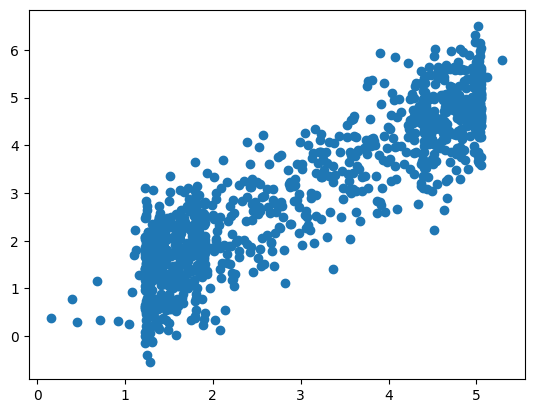

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_main, y_aux) 

In [ ]:
# =========================================================
# EXTRACT CURRENT BEST DESIGN AND CHECK VARIANCES
# =========================================================

best_design = gbfs.best_design

print("Objective:", gbfs.best_criteria_value)

print(
    "NHT Var aux / 10000:",
    nht_variance_for_variable(best_design, y_aux) / 10000
)

print(
    "NHT Var main / 10000:",
    nht_variance_for_variable(best_design, y_main) / 10000
)

print(
    "MI:",
    best_design.moran[0]
)

print(
    "Support size:",
    len(best_design.all_samples_and_probs[0])
)

print(
    "Sum probs:",
    best_design.all_samples_and_probs[1].sum()
)

Objective: -1.8862465928697292
NHT Var aux / 10000: 0.0023546027666813928
NHT Var main / 10000: 1.0893476168860177
MI: -0.31712146871242564
Support size: 20
Sum probs: 1.0


In [ ]:
# =========================================================
# ALL NHT ESTIMATORS FOR A DESIGN
# =========================================================

def nht_estimators(design, y):

    samples, probs = design.all_samples_and_probs
    pik = design.pop.inclusions

    ht = np.sum(
        y[samples] / pik[samples],
        axis=1
    )

    return ht, probs


# =========================================================
# AUXILIARY
# =========================================================

ht_aux, probs = nht_estimators(best_design, y_aux)

print("AUX true total:", y_aux.sum())
print("AUX NHT estimators:")
print(ht_aux)
print("AUX probs:")
print(probs)
print("AUX variance:", np.sum(probs * (ht_aux - y_aux.sum())**2) / 10000)


# =========================================================
# MAIN
# =========================================================

ht_main, probs = nht_estimators(best_design, y_main)

print("\nMAIN true total:", y_main.sum())
print("MAIN NHT estimators:")
print(ht_main)
print("MAIN probs:")
print(probs)
print("MAIN variance:", np.sum(probs * (ht_main - y_main.sum())**2) / 10000)

AUX true total: 3.268496584496461e-13
AUX NHT estimators:
[ 2.03530553  2.37601307 -0.5179482   6.31730308 -8.65401305  0.74610488
 -4.74685086  3.00239327  0.82459463  8.07345512  3.37175407  0.65842596
 -0.12249554 -7.24431464 -7.45601981  2.73507386  5.76736026 -1.36739929
  2.96512805 -8.76387041]
AUX probs:
[0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05]
AUX variance: 0.0023546027666813928

MAIN true total: 2999.3156558692144
MAIN NHT estimators:
[2955.12335367 2899.18818226 2885.78012389 2827.24077049 2791.29277739
 2932.8064523  3012.62201646 2987.03022266 3025.25670023 2851.06740206
 3100.12312625 3082.7105932  3125.41942004 3164.11915002 3090.79133303
 3119.09012093 3049.74028325 3016.05065813 2988.57223998 3082.28819116]
MAIN probs:
[0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05]
MAIN variance: 1.0893476168860177


In [ ]:
# Save a GRIZZLY
current_file = save_gbfs_state(gbfs)

In [ ]:
best_design = gbfs.best_design
best_design.nht_variance

66.38647984723404

### Global Searching Flatten GRIZZLY!

In [ ]:
# 1. Flatten the entire frontier

# 2. Grab the order from the NEW, flattened design
test_order = gbfs_global.best_design.order.copy()

--- Global Release Initiated ---
Processing 9880 candidates from the frontier...


✅ Success! New engine populated with 9881 global candidates.
Current Best Score: -0.430736


In [ ]:
test_order.change(
    num_clusters=1, 
    num_zones=1, 
    num_changes=1, 
    num_zone_changes=0, 
    window=120, 
    coords=pop.coords, 
    debugger_func=audit_intelligent_swap
)

TypeError: audit_intelligent_swap() got an unexpected keyword argument 'order'

In [ ]:
# 1. Flatten / release Grizzly
gbfs_global = release_full_grizzly(gbfs)

# 2. Check flattened order
test_order = gbfs_global.best_design.order.copy()

# 3. Run global Grizzly
gbfs_global.run(
    max_iterations=1000,
    max_open_set_size=2000,
    top_k=1,

    num_new_order_nodes=80,
    num_new_exchange_nodes=0,

    num_clusters_range=(1, 1),
    num_zones_range=(1, 1),
    num_changes_range=(1, 1),
    num_zone_changes=0,

    pull_strategy="default",
    exchange_coef=0.005,

    num_explore=1,
    window=20,

    n_jobs=2,
    backtrack_depth=20,
    stagnation_limit=5000,
    output_details=False,

    y_main=y_main,
    y_aux=y_aux,
)

--- Global Release Initiated ---
Processing 0 candidates from the frontier...
✅ Success! New engine populated with 1 global candidates.
Current Best Score: 3.546750
Starting fresh: Initializing Open Set.
--- Parallel GBFS: Batch Size=1, Workers=2 ---
    GAP USED: [10]
ITR/SuccR    0/1.000 | OBJ 3.543277 | VAR_main 1.150082 | VAR_aux 0.841250 | MI -0.39091 |  1C x  1Z | SIZ  20 | ENT 2.9957
    GAP USED: [3]
ITR/SuccR    0/2.000 | OBJ 3.527368 | VAR_main 1.165339 | VAR_aux 0.838725 | MI -0.39062 |  1C x  1Z | SIZ  20 | ENT 2.9957
    GAP USED: [9]
ITR/SuccR    0/3.000 | OBJ 3.424826 | VAR_main 1.150016 | VAR_aux 0.824317 | MI -0.39090 |  1C x  1Z | SIZ  20 | ENT 2.9957
    GAP USED: [3]
ITR/SuccR    0/4.000 | OBJ 3.103155 | VAR_main 1.103734 | VAR_aux 0.777224 | MI -0.38957 |  1C x  1Z | SIZ  20 | ENT 2.9957
    GAP USED: [4]
ITR/SuccR    1/2.500 | OBJ 3.042141 | VAR_main 1.092814 | VAR_aux 0.766401 | MI -0.38711 |  1C x  1Z | SIZ  20 | ENT 2.9957
    GAP USED: [19]
ITR/SuccR    1/3.00

KeyboardInterrupt: 